# Chapter 6: Scaling & Transformations

In [29]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib as mpl
import matplotlib.pyplot as plt

## 6.1: Introduction

Today, we'll learn about scaling and transforming data. Scaling adjusts data to a common scale, like converting measurements to the same units. This prevents one feature from dominating others in analysis or machine learning.

We'll explore techniques like Z-score normalization and Min-Max scaling.

We'll use the Pokemon dataset again to see these in action.

In [30]:
pokemon = pd.read_csv("Pokemon.csv", sep=";")
pokemon.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## 6.2: Statistics recap

Let's review some key statistics from the previous lesson: mean, median, and standard deviation. These describe the center and spread of data.

We'll calculate them for the 'Total' column in the Pokemon data.

In [31]:
pokemon['Total'].mean()

np.float64(435.1025)

In [32]:
pokemon['Total'].median()

450.0

In [33]:
pokemon['Total'].std()

119.963039755519

Lets's also create a histogram to show this.

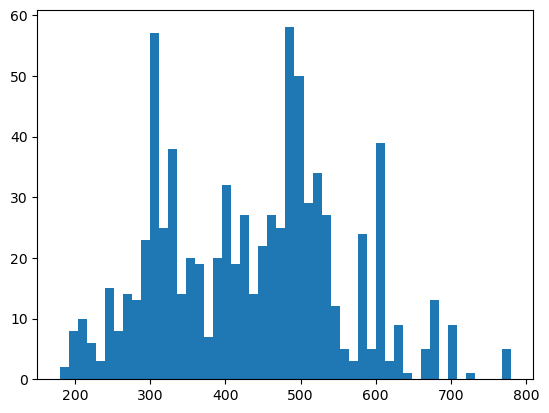

In [34]:
plt.hist(pokemon['Total'], bins = 50)
plt.show()

### Question 1: How can we visualise the median and standard deviation on this plot?

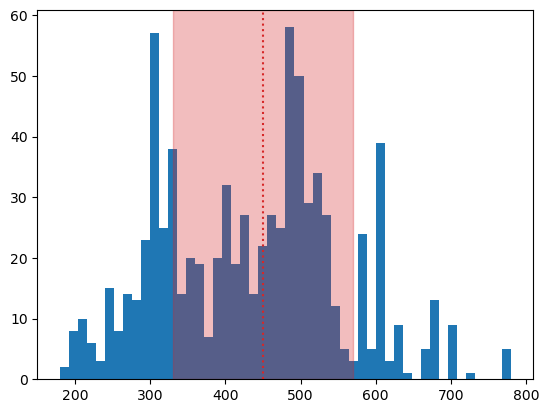

In [35]:
median = pokemon['Total'].median()
std = pokemon['Total'].std()

plt.hist(pokemon['Total'], bins = 50)
plt.axvline(median, zorder = 1, color = 'tab:red', linestyle = "dotted")
plt.axvspan(median - std, median + std, zorder = 1, color = 'tab:red', alpha = 0.3)
plt.show()

## 6.3: Centralization

Centering data is like moving a group of numbers so their average is at zero. We subtract the mean from each value. This removes any offset and helps algorithms work better.

To center the data, calculate the mean and subtract it from every value.

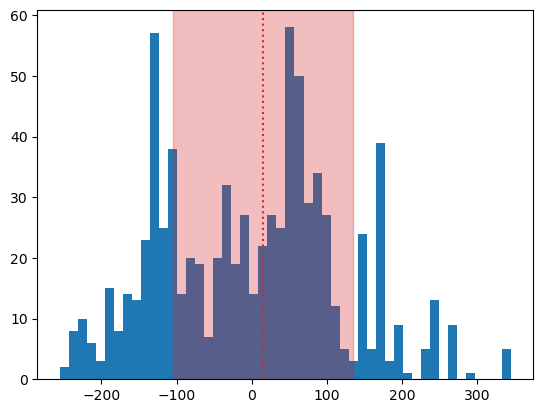

In [36]:
mean = pokemon['Total'].mean()
total_center = pokemon['Total'] - mean

median = total_center.median()
std = total_center.std()

plt.hist(total_center, bins=50)
plt.axvline(median, zorder = 1, color = 'tab:red', linestyle = "dotted")
plt.axvspan(median - std, median + std, zorder = 1, color = 'tab:red', alpha = 0.3)
plt.show()

### Question 2: Write a function that takes a single column as input, and outputs a centralised column instead.

In [37]:
def EnhanceData(data):
    data_center = data.mean()
    data_centralised = data - data_center
    
    return data_centralised

## 6.4: Normalization

Normalization standardizes data to a common scale. Two main methods are Z-score and Min-Max.

Z-score normalization centers the data at zero and scales it so the standard deviation is 1. This makes data comparable.

It centers first, then divides by the standard deviation.

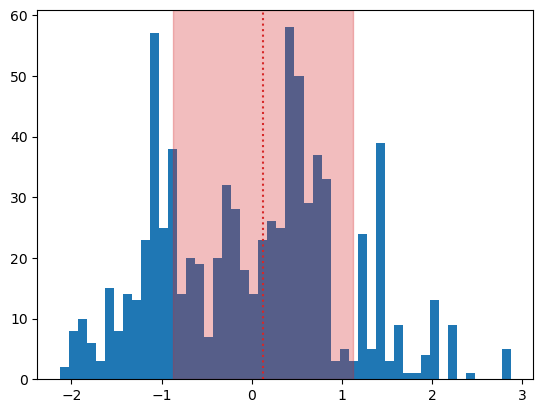

In [38]:
total_center_std = total_center.std()
total_zscore = total_center / total_center_std

total_zscore_median = total_zscore.median()
total_zscore_std = total_zscore.std()

plt.hist(total_zscore, bins=50)
plt.axvline(total_zscore_median, zorder = 1, color = 'tab:red', linestyle = "dotted")
plt.axvspan(total_zscore_median - total_zscore_std, total_zscore_median + total_zscore_std, zorder = 1, color = 'tab:red', alpha = 0.3)

Python has built-in tools for this in the sklearn library.

In [39]:
data_to_scale = pokemon['Total'].values.reshape((len(pokemon['Total']), 1))
scaler = preprocessing.StandardScaler()
scaler = scaler.fit(data_to_scale)
normalized = scaler.transform(data_to_scale)

### Question 3: Plot this data in a histogram and compare. Make sure to also visualise the median and standard deviation!

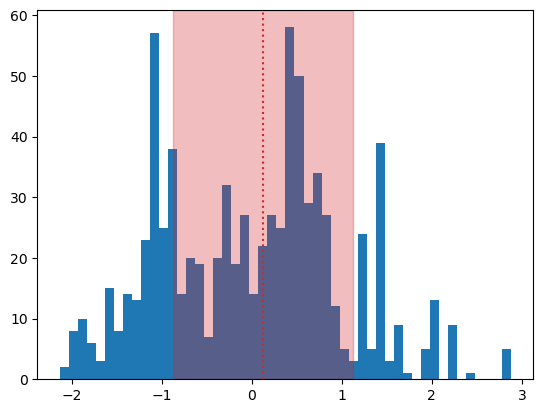

In [40]:
normalized_median = np.median(normalized)
normalized_std = normalized.std()

plt.hist(normalized, bins=50)
plt.axvline(normalized_median, zorder = 1, color = 'tab:red', linestyle = "dotted")
plt.axvspan(normalized_median - normalized_std, normalized_median + normalized_std, zorder = 1, color = 'tab:red', alpha = 0.3)

Another common technique is Min-Max scaling. It rescales data to a range between 0 and 1. This is useful when data must be in a specific range, like for some machine learning algorithms.

Python provides MinMaxScaler for this.

In [41]:
data_to_scale = pokemon['HP'].values.reshape((len(pokemon['Total']), 1))
scaler = preprocessing.MinMaxScaler()
scaler = scaler.fit(data_to_scale)
normalized = scaler.transform(data_to_scale)

### Question 4: Visualise the new histogram. Once again, show the median and the standard deviation. Do you notice the differences between both normalization techniques?

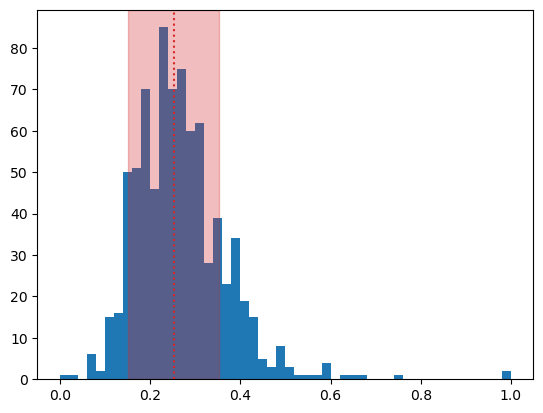

In [42]:
normalized_median = np.median(normalized)
normalized_std = normalized.std()

plt.hist(normalized, bins=50)
plt.axvline(normalized_median, zorder = 1, color = 'tab:red', linestyle = "dotted")
plt.axvspan(normalized_median - normalized_std, normalized_median + normalized_std, zorder = 1, color = 'tab:red', alpha = 0.3)

### Question 5: Build on your previous function. Allow for an aditional string parameter to be passed which can be either 'z-score' or 'minmax' and dictates which normalization technique should be used.

In [43]:
def EnhanceData(data, technique = ''):
    data_center = data.mean()
    data_normalized = data - data_center

    if technique == 'z-score':
        data_to_scale = data.values.reshape((len(data), 1))
        scaler = preprocessing.StandardScaler()
        scaler = scaler.fit(data_to_scale)
        data_normalized = scaler.transform(data_to_scale)
    elif technique == 'minmax':
        data_to_scale = data.values.reshape((len(data), 1))
        scaler = preprocessing.MinMaxScaler()
        scaler = scaler.fit(data_to_scale)
        data_normalized = scaler.transform(data_to_scale)
    
    return data_normalized

(array([ 29.,  73., 154.,  97., 115., 198.,  49.,  52.,  27.,   6.]),
 array([-255.1025, -195.1025, -135.1025,  -75.1025,  -15.1025,   44.8975,
         104.8975,  164.8975,  224.8975,  284.8975,  344.8975]),
 <BarContainer object of 10 artists>)

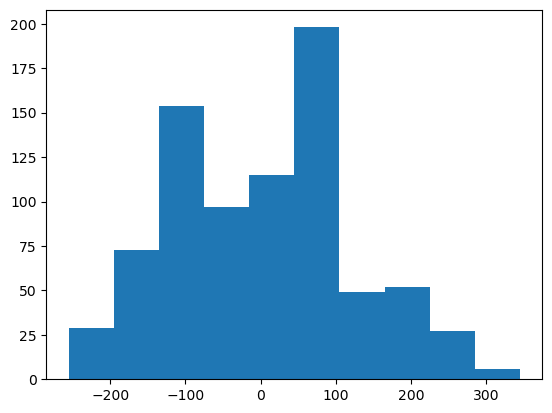

In [44]:
plt.hist(EnhanceData(pokemon['Total']))

(array([ 31.,  90., 135.,  97., 115., 207.,  77.,  15.,  27.,   6.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

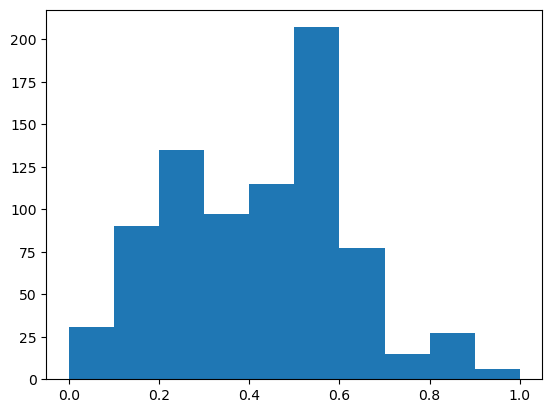

In [45]:
plt.hist(EnhanceData(pokemon['Total'], 'minmax'))

## 6.5: Transformations

Log transformations help when data spans a wide range, making large and small values comparable. For example, incomes vary greatly, with a few very high ones. Taking the log compresses the range, revealing patterns.

Examples: company sales of cheap and expensive items, or house prices including mansions.

Usually, apply log base 10.

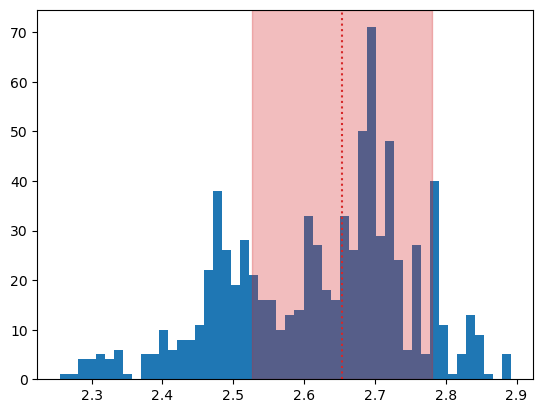

In [46]:
total_log = pokemon['Total'].apply(np.log10)

total_log_median = np.median(total_log)
total_log_std = total_log.std()

plt.hist(total_log, bins=50)
plt.axvline(total_log_median, zorder = 1, color = 'tab:red', linestyle = "dotted")
plt.axvspan(total_log_median - total_log_std, total_log_median + total_log_std, zorder = 1, color = 'tab:red', alpha = 0.3)

### Question 6: Add logarithmic scaling to your function to create the final master data scaling and transformation function!

In [47]:
def EnhanceData(data, technique = ''):
    data_log = data.apply(np.log10)
    
    data_center = data_log.mean()
    data_normalized = data_log - data_center

    if technique == 'z-score':
        data_to_scale = data.values.reshape((len(data), 1))
        scaler = preprocessing.StandardScaler()
        scaler = scaler.fit(data_to_scale)
        data_normalized = scaler.transform(data_to_scale)
    elif technique == 'minmax':
        data_to_scale = data.values.reshape((len(data), 1))
        scaler = preprocessing.MinMaxScaler()
        scaler = scaler.fit(data_to_scale)
        data_normalized = scaler.transform(data_to_scale)
    
    return data_normalized

(array([ 1.,  1.,  4.,  4.,  5.,  4.,  6.,  1.,  0.,  5.,  5., 10.,  6.,
         8.,  8., 11., 22., 38., 26., 19., 28., 21., 16., 16., 10., 13.,
        14., 33., 27., 18., 16., 33., 26., 50., 71., 29., 48., 24.,  6.,
        27.,  5., 40., 11.,  1.,  5., 13.,  9.,  1.,  0.,  5.]),
 array([-0.365676  , -0.35293956, -0.34020311, -0.32746667, -0.31473023,
        -0.30199379, -0.28925735, -0.2765209 , -0.26378446, -0.25104802,
        -0.23831158, -0.22557514, -0.21283869, -0.20010225, -0.18736581,
        -0.17462937, -0.16189293, -0.14915648, -0.13642004, -0.1236836 ,
        -0.11094716, -0.09821072, -0.08547427, -0.07273783, -0.06000139,
        -0.04726495, -0.03452851, -0.02179206, -0.00905562,  0.00368082,
         0.01641726,  0.0291537 ,  0.04189015,  0.05462659,  0.06736303,
         0.08009947,  0.09283591,  0.10557235,  0.1183088 ,  0.13104524,
         0.14378168,  0.15651812,  0.16925456,  0.18199101,  0.19472745,
         0.20746389,  0.22020033,  0.23293677,  0.24567322,

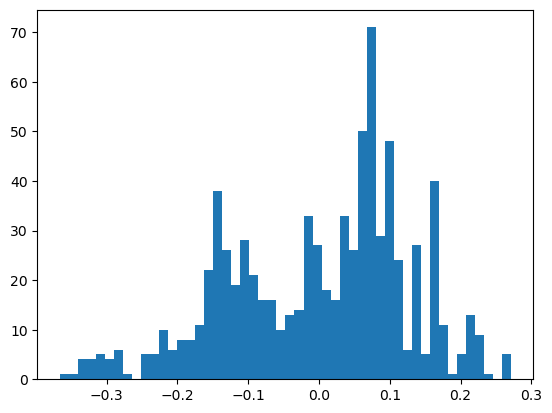

In [48]:
plt.hist(EnhanceData(pokemon["Total"], 'zscore'), bins=50)

## 6.6: Comparing Transformations

To see the effects of our transformations, let's compare histograms of the raw data with the scaled and transformed versions. This will show how each method changes the distribution.

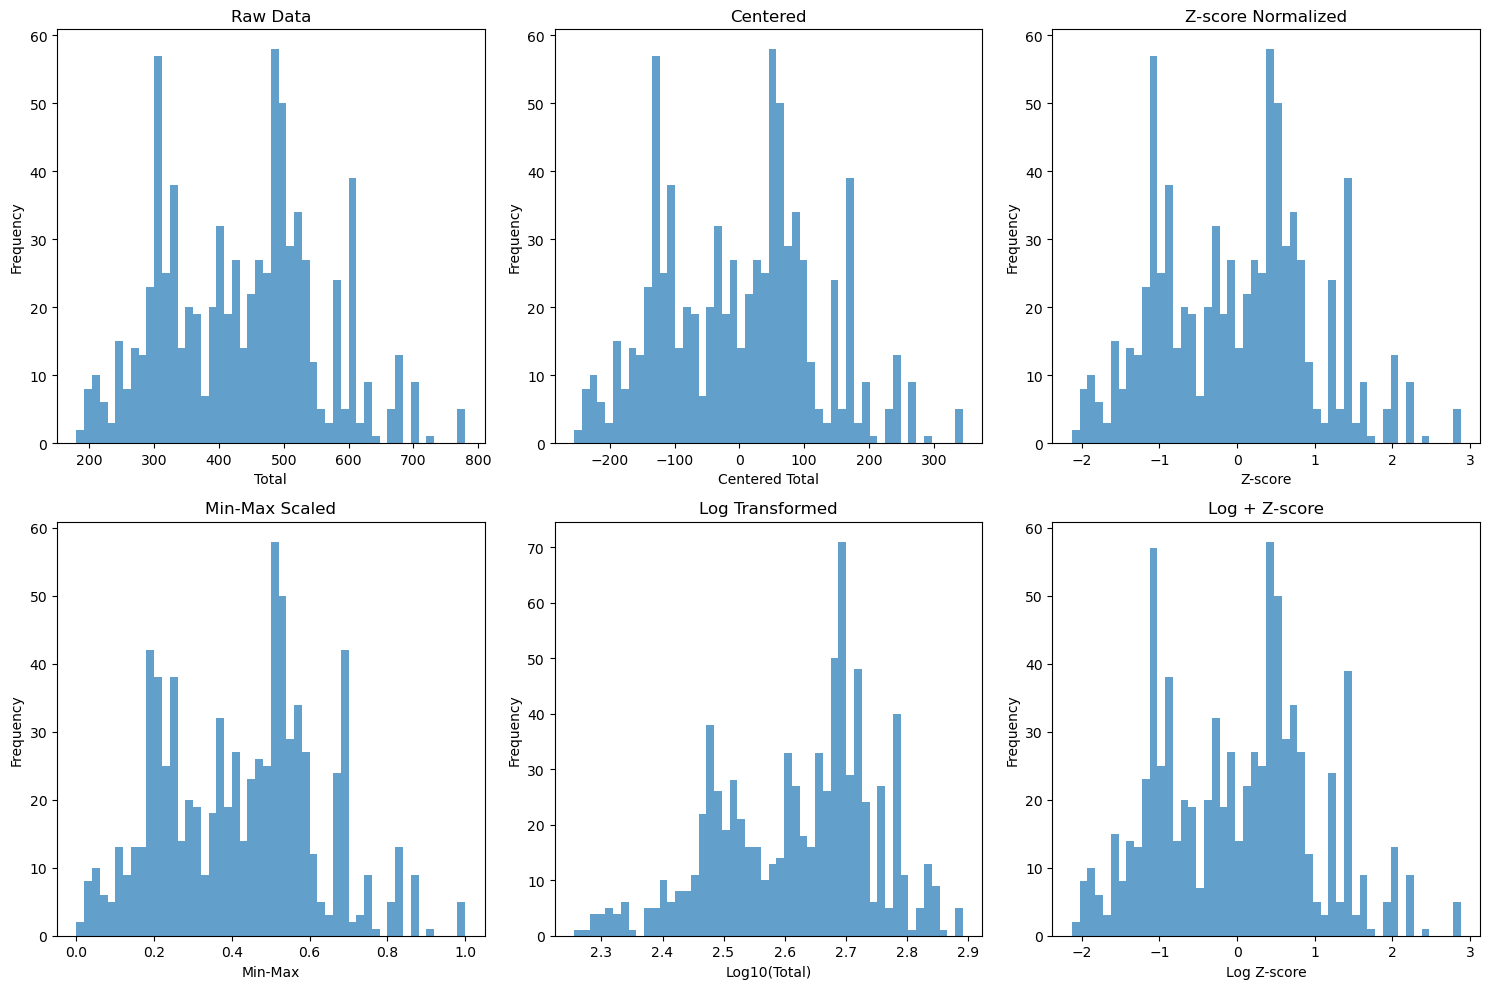

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Raw data
axes[0,0].hist(pokemon['Total'], bins=50, alpha=0.7)
axes[0,0].set_title('Raw Data')
axes[0,0].set_xlabel('Total')
axes[0,0].set_ylabel('Frequency')

# Centered
mean_total = pokemon['Total'].mean()
centered = pokemon['Total'] - mean_total
axes[0,1].hist(centered, bins=50, alpha=0.7)
axes[0,1].set_title('Centered')
axes[0,1].set_xlabel('Centered Total')
axes[0,1].set_ylabel('Frequency')

# Z-score normalized
data_to_scale = pokemon['Total'].values.reshape(-1, 1)
scaler_z = preprocessing.StandardScaler()
zscore = scaler_z.fit_transform(data_to_scale)
axes[0,2].hist(zscore, bins=50, alpha=0.7)
axes[0,2].set_title('Z-score Normalized')
axes[0,2].set_xlabel('Z-score')
axes[0,2].set_ylabel('Frequency')

# Min-Max scaled
scaler_mm = preprocessing.MinMaxScaler()
minmax = scaler_mm.fit_transform(data_to_scale)
axes[1,0].hist(minmax, bins=50, alpha=0.7)
axes[1,0].set_title('Min-Max Scaled')
axes[1,0].set_xlabel('Min-Max')
axes[1,0].set_ylabel('Frequency')

# Log transformed
log_transformed = pokemon['Total'].apply(np.log10)
axes[1,1].hist(log_transformed, bins=50, alpha=0.7)
axes[1,1].set_title('Log Transformed')
axes[1,1].set_xlabel('Log10(Total)')
axes[1,1].set_ylabel('Frequency')

# Log + Z-score (from function)
log_zscore = EnhanceData(pokemon['Total'], 'z-score')
axes[1,2].hist(log_zscore, bins=50, alpha=0.7)
axes[1,2].set_title('Log + Z-score')
axes[1,2].set_xlabel('Log Z-score')
axes[1,2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Notice how each transformation changes the data:
- **Centered**: Shifts to center at zero, same spread.
- **Z-score**: Centers at zero with standard deviation of 1.
- **Min-Max**: Scales to 0-1 range.
- **Log**: Compresses large values, making distribution more normal.
- **Log + Z-score**: Applies log first, then Z-score normalization.

This visual comparison helps understand when to use each method.